# Task 1.2 — Offering Strategy Under a Two-Price Balancing Scheme

**Assignment 2 — Renewables in Electricity Markets (46755, DTU)**

---

## Objective

Repeat Task 1.1 under the **two-price balancing scheme**: determine the optimal day-ahead (DA) offering strategy for a price-taking 500 MW wind farm, compute the expected profit, illustrate the profit distribution, and compare with the one-price results.

---

## What is the Two-Price Scheme?

Under the **two-price** balancing mechanism, the settlement price that the wind farm receives for its imbalance depends on **whether its deviation helps or hurts the power system**:

| System state | Wind farm deviation | Settlement price applied to imbalance |
|---|---|---|
| Deficit (SI = 1) | Over-production δ⁺ → **beneficial** | λ_B = 1.25 × λ_DA  *(rewarded at balancing price)* |
| Deficit (SI = 1) | Under-production δ⁻ → **harmful**   | λ_DA                *(penalised at DA price, NOT λ_B)* |
| Surplus (SI = 0) | Under-production δ⁻ → **beneficial** | λ_B = 0.85 × λ_DA  *(rewarded at balancing price)* |
| Surplus (SI = 0) | Over-production δ⁺  → **harmful**   | λ_DA                *(penalised at DA price, NOT λ_B)* |

**Key idea:** under two-price, a *beneficial* imbalance is rewarded at the balancing price (which is either high or low depending on system state), while a *harmful* imbalance is only penalised at the day-ahead price. This asymmetry **always favours** the wind farm compared to one-price, where *all* imbalances are settled at λ_B regardless of their direction.

---

## Profit Formulas

Let $\delta^+_{t,\omega} = \max(0,\, W_{t,\omega} - p_t^{DA})$ (over-production) and $\delta^-_{t,\omega} = \max(0,\, p_t^{DA} - W_{t,\omega})$ (under-production).

**If SI = 1 (deficit system):**
$$
\Pi_{t,\omega} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \lambda^{B}_{t,\omega} \cdot \delta^+_{t,\omega} - \lambda^{DA}_{t,\omega} \cdot \delta^-_{t,\omega}
$$

**If SI = 0 (surplus system):**
$$
\Pi_{t,\omega} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \lambda^{B}_{t,\omega} \cdot \delta^-_{t,\omega} - \lambda^{DA}_{t,\omega} \cdot \delta^+_{t,\omega}
$$

where $\lambda^{B}_{t,\omega} = 1.25 \cdot \lambda^{DA}_{t,\omega}$ if SI=1, and $\lambda^{B}_{t,\omega} = 0.85 \cdot \lambda^{DA}_{t,\omega}$ if SI=0.

---

## Stochastic Optimisation Problem

$$
\max_{p_t^{DA}} \; \frac{1}{|\Omega|} \sum_{\omega \in \Omega} \sum_{t=1}^{24} \Pi_{t,\omega}
$$

subject to:
$$
0 \leq p_t^{DA} \leq P_{\max} = 500 \text{ MW}, \quad \forall t
$$
$$
W_{t,\omega} - p_t^{DA} = \delta^+_{t,\omega} - \delta^-_{t,\omega}, \quad \forall t, \omega
$$
$$
\delta^+_{t,\omega},\; \delta^-_{t,\omega} \geq 0, \quad \forall t, \omega
$$

Note that $\delta^+$ and $\delta^-$ are **second-stage (recourse) variables**: they are decided after the scenario is revealed, so they can vary per scenario. The first-stage decision $p_t^{DA}$ must be fixed before uncertainty is resolved.

---

## Contrast with One-Price

Under the **one-price** scheme (Task 1.1), the profit is simply:
$$
\Pi_{t,\omega}^{\text{1P}} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \left(W_{t,\omega} - p_t^{DA}\right) \cdot \lambda^{B}_{t,\omega}
$$
There are no $\delta^+$ / $\delta^-$ variables — the *entire* imbalance always gets λ_B. This means:
- One-price model has only $T = 24$ variables → can handle all 1600 scenarios easily.
- Two-price model needs $T + 2 \times T \times N$ variables (δ⁺ and δ⁻ per scenario per hour).

In [16]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

## Step 1 — Load Scenario Data

We use the same three scenario files generated in the preprocessing step:
- **wind_realizations.csv**: 20 wind power scenarios × 24 hours (MW)
- **da_price_scenarios.csv**: 20 day-ahead price scenarios × 24 hours (€/MWh)
- **imbalance_scenarios_random.csv**: 4 system imbalance (SI) scenarios × 24 hours (0 = surplus, 1 = deficit)

Total combined scenarios = 20 × 20 × 4 = **1,600** (satisfies the ≥ 1,600 requirement).

In [17]:
# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

wind      = pd.read_csv('../data/processed/wind_realizations.csv')
price     = pd.read_csv('../data/processed/da_price_scenarios.csv')
imbalance = pd.read_csv('../data/processed/imbalance_scenarios_random.csv')

# Drop the 'Hour' index column; keep only the scenario columns
W         = wind.iloc[:, 1:].values       # shape: (24, 20)
lambda_DA = price.iloc[:, 1:].values      # shape: (24, 20)
SI        = imbalance.iloc[:, 1:].values  # shape: (24, 4)  — 0=surplus, 1=deficit

# Problem constants
T     = 24       # hours in a day
P_max = 500.0    # installed capacity [MW]

N_w = W.shape[1]         # 20 wind scenarios
N_p = lambda_DA.shape[1] # 20 price scenarios
N_s = SI.shape[1]        # 4 imbalance scenarios

print(f'Wind shape:      {W.shape}   ({N_w} scenarios)')
print(f'Price shape:     {lambda_DA.shape}   ({N_p} scenarios)')
print(f'Imbalance shape: {SI.shape}    ({N_s} scenarios)')

Wind shape:      (24, 20)   (20 scenarios)
Price shape:     (24, 20)   (20 scenarios)
Imbalance shape: (24, 4)    (4 scenarios)


## Step 2 — Build All 1,600 Combined Scenarios

We form the Cartesian product of the three independent uncertainty sources:
- Each combined scenario ω = (wind scenario i, price scenario j, imbalance scenario k)
- All 1,600 scenarios are equally probable: π_ω = 1/1600

The balancing price is derived from the DA price and system imbalance state:
- **Deficit** (SI=1): λ_B = 1.25 × λ_DA
- **Surplus** (SI=0): λ_B = 0.85 × λ_DA

In [18]:
# ============================================================
# STEP 2 — BUILD FULL CARTESIAN SCENARIO SET (1,600 scenarios)
# ============================================================

# Repeat wind: each wind scenario is repeated N_p*N_s times (for every price/SI combo)
W_full = np.repeat(W, N_p * N_s, axis=1)                         # (24, 1600)

# Tile price: repeat each price scenario N_s times, then tile over all wind scenarios
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))  # (24, 1600)

# Tile imbalance: tile SI across all wind × price combinations
SI_full = np.tile(SI, (1, N_w * N_p))                            # (24, 1600)

# Compute balancing price for each combined scenario
# Deficit  (SI=1): λ_B = 1.25 × λ_DA  (balancing price > DA price)
# Surplus  (SI=0): λ_B = 0.85 × λ_DA  (balancing price < DA price)
lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_full = W_full.shape[1]  # should be 1600
print(f'Total combined scenarios: {N_full}  (>= 1600: {N_full >= 1600})')
print(f'Combined matrix shape: {W_full.shape}')
print(f'\nDeficit fraction across scenarios: {SI_full.mean():.2%}')

Total combined scenarios: 1600  (>= 1600: True)
Combined matrix shape: (24, 1600)

Deficit fraction across scenarios: 47.92%


## Step 3 — Re-solve Task 1.1 (One-Price) for Comparison

We solve the one-price model on all 1,600 scenarios here to have a fair baseline for comparison. The one-price model is simple because there are **no δ⁺/δ⁻ recourse variables** — the whole imbalance $(W - p^{DA})$ is settled at λ_B. This means only 24 variables, so all 1,600 scenarios are tractable.

In [19]:
# ============================================================
# STEP 3 — TASK 1.1 ONE-PRICE MODEL (all 1600 scenarios)
# Used only to reproduce 1P results for the final comparison plot.
# ============================================================

m1 = gp.Model('one_price')
m1.setParam('OutputFlag', 0)  # suppress solver output for cleanliness

# First-stage decision: day-ahead offer per hour
p1 = m1.addVars(T, lb=0.0, ub=P_max, name='p_DA')

# Build objective: max expected profit under one-price settlement
# Profit_1P = λ_DA * p_DA + (W - p_DA) * λ_B
#           = W * λ_B + p_DA * (λ_DA - λ_B)
# Since W*λ_B is a constant w.r.t. p_DA, the optimal p_DA depends only on
# the sign of E[λ_DA - λ_B] → bang-bang (all-or-nothing) solution
obj1 = gp.LinExpr()
for t in range(T):
    for w in range(N_full):
        obj1 += (1.0 / N_full) * (
            p1[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p1[t]) * lambda_B_full[t, w]
        )

m1.setObjective(obj1, GRB.MAXIMIZE)
m1.optimize()

# Extract results
p_opt_1p = np.array([p1[t].X for t in range(T)])
obj_1p   = m1.ObjVal

# Compute per-scenario profits for the one-price offers
profits_1p = np.zeros(N_full)
for w in range(N_full):
    for t in range(T):
        profits_1p[w] += (
            p_opt_1p[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_opt_1p[t]) * lambda_B_full[t, w]
        )

print('=== Task 1.1 — One-Price Results ===')
print(f'Expected profit : €{obj_1p:>12,.2f}')
print(f'Std of profit   : €{profits_1p.std():>12,.2f}')
print(f'Hours at   0 MW : {sum(p_opt_1p < 1)}')
print(f'Hours at 500 MW : {sum(p_opt_1p > 499)}')

=== Task 1.1 — One-Price Results ===
Expected profit : €  464,595.22
Std of profit   : €  340,871.49
Hours at   0 MW : 15
Hours at 500 MW : 9


## Step 4 — Two-Price Model: Licence Constraint & Scenario Reduction

The two-price model introduces **per-scenario recourse variables** $\delta^+_{t,\omega}$ and $\delta^-_{t,\omega}$.

**Variable count:**
$$
\text{Variables} = T + 2 \times T \times N = 24 + 48N
$$

The Gurobi **free/academic licence** limits us to **≤ 2,000 variables**:
$$
24 + 48N \leq 2000 \implies N \leq 41
$$

We therefore **randomly sample N = 40 scenarios** from the 1,600-scenario pool. The optimised offers will then be evaluated on all 1,600 scenarios to get a fair comparison with Task 1.1.

In [20]:
# ============================================================
# STEP 4 — SCENARIO REDUCTION FOR TWO-PRICE MODEL
#
# The two-price model requires per-scenario recourse variables
# δ⁺[t,w] and δ⁻[t,w], which grows the variable count to:
#   T + 2*T*N  variables
#   T*N        constraints (imbalance equalities)
#
# Gurobi free licence limit: 2000 variables → max N = 41 scenarios.
# We use N = 40 for a safe margin.
# ============================================================

N_sample = 40   # scenarios used in the two-price optimisation

# Verify we stay within the Gurobi free licence limit
n_vars   = T + 2 * T * N_sample   # p_DA[T] + delta_pos[T,N] + delta_neg[T,N]
n_constrs = T * N_sample           # one imbalance equality per (t, w)
assert n_vars <= 2000,   f'Variable limit exceeded: {n_vars} > 2000'
assert n_constrs <= 2000, f'Constraint limit exceeded: {n_constrs} > 2000'
print(f'Variables:   {n_vars:4d}  (limit: 2000 ✓)')
print(f'Constraints: {n_constrs:4d}  (limit: 2000 ✓)')

# Random sample (seed for reproducibility)
np.random.seed(42)
selected = np.random.choice(N_full, N_sample, replace=False)

# Subset scenario arrays to the N_sample selected columns
W_s         = W_full[:, selected]          # (24, 40)
lambda_DA_s = lambda_DA_full[:, selected]  # (24, 40)
lambda_B_s  = lambda_B_full[:, selected]   # (24, 40)
SI_s        = SI_full[:, selected]         # (24, 40)

N  = N_sample
pi = 1.0 / N   # equal probability weight per scenario

print(f'\nSampled {N} scenarios from {N_full} for two-price optimisation.')
print(f'Wind range:    [{W_s.min():.1f}, {W_s.max():.1f}] MW')
print(f'Price range:   [{lambda_DA_s.min():.2f}, {lambda_DA_s.max():.2f}] €/MWh')
print(f'Deficit frac:  {SI_s.mean():.2%}')

Variables:   1944  (limit: 2000 ✓)
Constraints:  960  (limit: 2000 ✓)

Sampled 40 scenarios from 1600 for two-price optimisation.
Wind range:    [3.3, 482.1] MW
Price range:   [1.00, 466.44] €/MWh
Deficit frac:  46.98%


## Step 5 — Build & Solve the Two-Price Optimisation Model

**Decision variables:**
- $p_t^{DA}$ — first-stage: DA offer at hour $t$ (same for all scenarios)
- $\delta^+_{t,\omega}$ — second-stage: over-production in scenario $\omega$ at hour $t$
- $\delta^-_{t,\omega}$ — second-stage: under-production in scenario $\omega$ at hour $t$

**Imbalance decomposition constraint:**  
$$W_{t,\omega} - p_t^{DA} = \delta^+_{t,\omega} - \delta^-_{t,\omega}$$

Combined with non-negativity, this ensures at most one of $\delta^+$, $\delta^-$ is non-zero per scenario per hour (since wind power is non-negative and $p^{DA} \leq P_{max}$, the LP relaxation correctly handles this without explicit binary variables).

In [21]:
# ============================================================
# STEP 5 — BUILD TWO-PRICE GUROBI MODEL
# ============================================================

m2 = gp.Model('two_price')
m2.setParam('OutputFlag', 1)  # show solver log

# ── First-stage variable (must be decided before uncertainty is revealed) ─────
# p_DA[t]: energy offered to the day-ahead market at hour t
p2 = m2.addVars(T, lb=0.0, ub=P_max, name='p_DA')

# ── Second-stage recourse variables (one per scenario per hour) ───────────────
# delta_pos[t,w]: over-production = max(0, W[t,w] - p_DA[t])
# delta_neg[t,w]: under-production = max(0, p_DA[t] - W[t,w])
# Both are non-negative and bounded by P_max
delta_pos = m2.addVars(T, N, lb=0.0, ub=P_max, name='dpos')
delta_neg = m2.addVars(T, N, lb=0.0, ub=P_max, name='dneg')

# ── Imbalance decomposition constraints ───────────────────────────────────────
# W[t,w] - p_DA[t] = δ⁺[t,w] - δ⁻[t,w]  for all t, w
# This links the first-stage decision p_DA to the second-stage imbalance.
# The LP structure ensures complementarity (no need for binary variables).
for t in range(T):
    for w in range(N):
        m2.addConstr(
            W_s[t, w] - p2[t] == delta_pos[t, w] - delta_neg[t, w],
            name=f'imbal_t{t}_w{w}'
        )

print(f'Model built.  Variables: {m2.NumVars}   Constraints: {m2.NumConstrs}')

Set parameter OutputFlag to value 1
Model built.  Variables: 0   Constraints: 0


## Step 6 — Two-Price Objective Function

The objective differs from one-price because the settlement **depends on the direction** of the imbalance relative to the system state:

**SI = 1 (deficit):** Over-production δ⁺ is beneficial → rewarded at λ_B (= 1.25 × λ_DA).  
Under-production δ⁻ is harmful → penalised at λ_DA (not λ_B, which would be cheaper).

**SI = 0 (surplus):** Under-production δ⁻ is beneficial → rewarded at λ_B (= 0.85 × λ_DA).  
Over-production δ⁺ is harmful → penalised at λ_DA (not λ_B, which would be higher).

This asymmetry makes two-price strictly **more profitable** than one-price for the wind farm: the wind farm never pays more than the DA price for a harmful deviation (whereas under one-price, a harmful deviation during deficit would be settled at 1.25×λ_DA).

In [22]:
# ============================================================
# STEP 6 — TWO-PRICE OBJECTIVE FUNCTION
# ============================================================

obj2 = gp.LinExpr()

for t in range(T):
    for w in range(N):
        lda = float(lambda_DA_s[t, w])  # day-ahead price in this scenario
        lb  = float(lambda_B_s[t, w])   # balancing price: 1.25*lda or 0.85*lda
        si  = int(SI_s[t, w])           # 1 = deficit, 0 = surplus

        # DA revenue is always λ_DA × p_DA regardless of scheme
        da_rev = lda * p2[t]

        if si == 1:
            # DEFICIT system:
            #   Over-production δ⁺ is BENEFICIAL → settled at λ_B = 1.25 × λ_DA
            #   Under-production δ⁻ is HARMFUL   → penalised at λ_DA (two-price protection)
            bal_rev = lb * delta_pos[t, w] - lda * delta_neg[t, w]
        else:
            # SURPLUS system:
            #   Under-production δ⁻ is BENEFICIAL → settled at λ_B = 0.85 × λ_DA
            #   Over-production δ⁺ is HARMFUL    → penalised at λ_DA (two-price protection)
            bal_rev = lb * delta_neg[t, w] - lda * delta_pos[t, w]

        # Accumulate: pi = 1/N (equal weights)
        obj2 += pi * (da_rev + bal_rev)

m2.setObjective(obj2, GRB.MAXIMIZE)
print('Two-price objective set.')

Two-price objective set.


In [23]:
# ============================================================
# STEP 7 — SOLVE
# ============================================================

m2.optimize()

STATUS = {1:'LOADED', 2:'OPTIMAL', 3:'INFEASIBLE', 4:'INF_OR_UNBD', 5:'UNBOUNDED'}
print(f'\nSolver status: {m2.status} ({STATUS.get(m2.status, "OTHER")})')

if m2.status == GRB.OPTIMAL:
    p_opt_2p = np.array([p2[t].X for t in range(T)])
    obj_2p   = m2.ObjVal
    print(f'\nExpected profit (two-price, in-sample): €{obj_2p:,.2f}')
    print('\nOptimal DA offers [MW]:')
    for t in range(T):
        mark = '← zero' if p_opt_2p[t] < 1 else ('← MAX' if p_opt_2p[t] > 499 else '')
        print(f'  Hour {t+1:2d}: {p_opt_2p[t]:6.1f} MW  {mark}')
else:
    raise RuntimeError(f'Solver did not find optimal solution. Status = {m2.status}')

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 960 rows, 1944 columns and 2880 nonzeros (Max)
Model fingerprint: 0x9ddeaaf2
Model has 1944 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [3e+00, 5e+02]

Presolve time: 0.00s
Presolved: 960 rows, 1944 columns, 2880 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.4340728e+06   5.742983e+04   0.000000e+00      0s
     994    1.1895317e+06   0.000000e+00   0.000000e+00      0s

Solved in 994 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.189531712e+06

Solver status: 2 (OPTIMAL)

Expected profit (two-price, in-sample): €1,189,531.71

Optimal DA offers [MW]:
  Hour  1:  500.0 MW  ← MAX
  Hour  2:  500

## Step 8 — Evaluate Two-Price Offers on All 1,600 Scenarios

The optimisation used only N = 40 scenarios (due to licence limits). To get a **fair comparison** with Task 1.1 (which used all 1,600), we now evaluate the obtained DA offers $p^{DA*}$ on all 1,600 scenarios. This is an **out-of-optimisation** evaluation — no new optimisation is run, just profit calculation.

In [24]:
# ============================================================
# STEP 8 — EVALUATE TWO-PRICE OFFERS ON ALL 1,600 SCENARIOS
#
# The optimisation used N=40 scenarios. Here we evaluate the
# optimal offers on the full 1,600 scenario set to ensure
# a fair comparison with Task 1.1.
# ============================================================

profits_2p = np.zeros(N_full)

for w in range(N_full):
    pw = 0.0
    for t in range(T):
        lda = float(lambda_DA_full[t, w])
        lb  = float(lambda_B_full[t, w])
        si  = int(SI_full[t, w])
        p   = p_opt_2p[t]                          # fixed first-stage decision

        # Compute actual imbalance for this scenario
        dp = max(0.0, W_full[t, w] - p)            # δ⁺ = over-production
        dn = max(0.0, p - W_full[t, w])            # δ⁻ = under-production

        # Two-price profit formula
        if si == 1:   # deficit: over-production is beneficial
            pw += lda * p + lb * dp - lda * dn
        else:         # surplus: under-production is beneficial
            pw += lda * p + lb * dn - lda * dp

    profits_2p[w] = pw

print('=== Task 1.2 — Two-Price (evaluated on all 1,600 scenarios) ===')
print(f'Expected profit : €{profits_2p.mean():>12,.2f}')
print(f'Std of profit   : €{profits_2p.std():>12,.2f}')
print(f'P10 (10th pctl) : €{np.percentile(profits_2p, 10):>12,.2f}')
print(f'P90 (90th pctl) : €{np.percentile(profits_2p, 90):>12,.2f}')
print(f'Min             : €{profits_2p.min():>12,.2f}')
print(f'Max             : €{profits_2p.max():>12,.2f}')
print(f'Hours at   0 MW : {sum(p_opt_2p < 1)}')
print(f'Hours at 500 MW : {sum(p_opt_2p > 499)}')

=== Task 1.2 — Two-Price (evaluated on all 1,600 scenarios) ===
Expected profit : €1,156,408.90
Std of profit   : €  414,910.28
P10 (10th pctl) : €  665,362.62
P90 (90th pctl) : €1,661,699.54
Min             : €  180,224.86
Max             : €2,445,668.10
Hours at   0 MW : 1
Hours at 500 MW : 23


## Step 9 — All-or-Nothing Bidding Check

Like in Task 1.1, we check whether the two-price solution also exhibits **bang-bang (all-or-nothing) bidding** behaviour.

Under the **two-price scheme**, the expected profit (for a given hour) can be written:

- In **deficit** scenarios (SI=1):
$$\Pi = \lambda^{DA} p + \lambda^B \delta^+ - \lambda^{DA} \delta^-$$

- In **surplus** scenarios (SI=0):
$$\Pi = \lambda^{DA} p + \lambda^B \delta^- - \lambda^{DA} \delta^+$$

Since $\delta^+ - \delta^- = W - p^{DA}$ and $\lambda^B \geq \lambda^{DA}$ in deficit (and $\lambda^B \leq \lambda^{DA}$ in surplus), the profit function is **still linear in $p^{DA}$** for each scenario, which again drives a bang-bang solution. However, the two-price asymmetry changes the relative marginal value of $p^{DA}$, potentially shifting some hours.

In [25]:
# ============================================================
# STEP 9 — ALL-OR-NOTHING BIDDING CHECK
# ============================================================

tol = 1.0  # 1 MW tolerance for numerical precision

hours_zero    = [t+1 for t in range(T) if p_opt_2p[t] < tol]
hours_cap     = [t+1 for t in range(T) if p_opt_2p[t] > P_max - tol]
hours_between = [t+1 for t in range(T) if tol <= p_opt_2p[t] <= P_max - tol]

print('=== All-or-Nothing Bidding Check (Two-Price) ===')
print(f'Hours offering   0 MW : {hours_zero}  ({len(hours_zero)} hours)')
print(f'Hours offering 500 MW : {hours_cap}  ({len(hours_cap)} hours)')
print(f'Intermediate offers   : {hours_between}  ({len(hours_between)} hours)')
frac_extreme = (len(hours_zero) + len(hours_cap)) / T
print(f'\nExtreme bids (0 or max): {frac_extreme:.0%} of hours')

if not hours_between:
    print('\n→ Perfect ALL-OR-NOTHING bidding observed under two-price scheme.')
    print('  Explanation: The expected profit is still linear in p_DA because')
    print('  the two-price profit is piecewise-linear (not strictly concave).')
    print('  The optimum therefore always lies at a corner: p_DA = 0 or P_max.')
else:
    print('\n→ Some intermediate offers observed (may be due to small sample size).')

=== All-or-Nothing Bidding Check (Two-Price) ===
Hours offering   0 MW : [14]  (1 hours)
Hours offering 500 MW : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]  (23 hours)
Intermediate offers   : []  (0 hours)

Extreme bids (0 or max): 100% of hours

→ Perfect ALL-OR-NOTHING bidding observed under two-price scheme.
  Explanation: The expected profit is still linear in p_DA because
  the two-price profit is piecewise-linear (not strictly concave).
  The optimum therefore always lies at a corner: p_DA = 0 or P_max.


In [26]:
# ============================================================
# STEP 13 — SAVE RESULTS FOR TASKS 1.3 AND 1.4
# ============================================================

# Save optimal DA offers
offers_df = pd.DataFrame({
    'hour':            range(1, T + 1),
    'p_DA_one_price':  p_opt_1p,
    'p_DA_two_price':  p_opt_2p
})
offers_df.to_csv('../data/processed/task1_2_offers.csv', index=False)

# Save per-scenario profits
profits_df = pd.DataFrame({
    'scenario_profit_one_price': profits_1p,
    'scenario_profit_two_price': profits_2p
})
profits_df.to_csv('../data/processed/task1_2_profits.csv', index=False)

print('Results saved to ../data/processed/')
print(offers_df.to_string(index=False))

Results saved to ../data/processed/
 hour  p_DA_one_price  p_DA_two_price
    1             0.0           500.0
    2           500.0           500.0
    3             0.0           500.0
    4           500.0           500.0
    5           500.0           500.0
    6           500.0           500.0
    7             0.0           500.0
    8             0.0           500.0
    9             0.0           500.0
   10           500.0           500.0
   11           500.0           500.0
   12             0.0           500.0
   13             0.0           500.0
   14             0.0             0.0
   15           500.0           500.0
   16           500.0           500.0
   17             0.0           500.0
   18             0.0           500.0
   19             0.0           500.0
   20           500.0           500.0
   21             0.0           500.0
   22             0.0           500.0
   23             0.0           500.0
   24             0.0           500.0


## Task 1.4 — Risk-Averse Offering Strategy: Two-Price Scheme

In this section, the two-price offering strategy is extended with a CVaR-based risk-averse objective.

The confidence level is fixed at:

$$
\alpha = 0.90
$$

The risk-aversion parameter is varied between 0 and 1:

$$
\beta \in [0,1]
$$

The objective combines expected profit and CVaR:

$$
\max \; (1-\beta)\mathbb{E}[\Pi_\omega] + \beta \text{CVaR}_{0.90}
$$

When \(\beta = 0\), the formulation is risk-neutral and maximizes expected profit. When \(\beta = 1\), the formulation focuses only on improving the worst 10% of profit outcomes.

### CVaR Definition

For each scenario \(\omega\), the auxiliary variable \(\zeta_\omega\) satisfies:

$$
\zeta_\omega \geq \eta - \Pi_\omega
$$

where \(\eta\) is the VaR level and \(\zeta_\omega\) measures the shortfall of scenario profit below this level.

The CVaR of profit is then:

$$
\text{CVaR}_{\alpha}
=
\eta
-
\frac{1}{1-\alpha}
\frac{1}{|\Omega|}
\sum_{\omega \in \Omega} \zeta_\omega
$$

Thus, maximizing CVaR improves the average profit in the worst \(1-\alpha\) fraction of scenarios.

In [27]:
alpha = 0.90
beta_values = np.linspace(0, 1, 11)

risk_results_2p = []
risk_offers_2p = []
risk_profits_2p = []

def solve_two_price_cvar(beta):

    model = gp.Model()
    model.setParam("OutputFlag", 0)

    # -----------------------------
    # Decision variables
    # -----------------------------
    p_DA = model.addVars(range(T), lb=0.0, ub=P_max, name="p_DA")

    delta_pos = model.addVars(range(T), range(N), lb=0.0, name="delta_pos")
    delta_neg = model.addVars(range(T), range(N), lb=0.0, name="delta_neg")

    # CVaR variables (LOSS formulation)
    eta = model.addVar(lb=-GRB.INFINITY, name="eta")
    zeta = model.addVars(range(N), lb=0.0, name="zeta")

    # -----------------------------
    # Imbalance constraint
    # -----------------------------
    for t in range(T):
        for w in range(N):
            model.addConstr(
                W_s[t, w] - p_DA[t] == delta_pos[t, w] - delta_neg[t, w]
            )

    # -----------------------------
    # Profit
    # -----------------------------
    profit = {}

    for w in range(N):

        terms = []

        for t in range(T):
            lda = float(lambda_DA_s[t, w])
            lb = float(lambda_B_s[t, w])
            si = int(SI_s[t, w])

            if si == 1:
                # deficit
                terms.append(
                    lda * p_DA[t]
                    + lda * delta_pos[t, w]
                    - lb * delta_neg[t, w]
                )
            else:
                # surplus
                terms.append(
                    lda * p_DA[t]
                    + lda * delta_neg[t, w]
                    - lb * delta_pos[t, w]
                )

        profit[w] = gp.quicksum(terms)

    expected_profit = gp.quicksum(profit[w] for w in range(N)) / N

    # -----------------------------
    # CVaR on LOSSES
    # -----------------------------
    loss = {w: -profit[w] for w in range(N)}

    for w in range(N):
        model.addConstr(zeta[w] >= loss[w] - eta)

    cvar_loss = eta + (1/(1-alpha)) * gp.quicksum(zeta[w] for w in range(N)) / N

    # -----------------------------
    # Objective
    # -----------------------------
    model.setObjective(
        (1-beta)*expected_profit - beta*cvar_loss,
        GRB.MAXIMIZE
    )

    model.optimize()

    if model.status != GRB.OPTIMAL:
        print("Model status:", model.status)
    return None

    # -----------------------------
    # Extract solution
    # -----------------------------
    p_sol = np.array([p_DA[t].X for t in range(T)])

    profits = np.zeros(N)

    for w in range(N):
        for t in range(T):

            lda = float(lambda_DA_s[t, w])
            lb = float(lambda_B_s[t, w])
            si = int(SI_s[t, w])
            p = p_sol[t]

            dp = max(0.0, W_s[t, w] - p)
            dn = max(0.0, p - W_s[t, w])

            if si == 1:
                profits[w] += lda*p + lda*dp - lb*dn
            else:
                profits[w] += lda*p + lda*dn - lb*dp

    sorted_p = np.sort(profits)
    n_tail = max(1, int((1-alpha)*N))

    cvar_profit = sorted_p[:n_tail].mean()

    return {
        "beta": beta,
        "p_DA": p_sol,
        "profits": profits,
        "expected_profit": profits.mean(),
        "std_profit": profits.std(),
        "CVaR": cvar_profit
    }


# ============================================
# RUN
# ============================================

for beta in beta_values:
    res = solve_two_price_cvar(beta)

    if res is not None:
        risk_results_2p.append(res)
        risk_offers_2p.append(res["p_DA"])
        risk_profits_2p.append(res["profits"])

risk_df_2p = pd.DataFrame({
    "beta": [r["beta"] for r in risk_results_2p],
    "expected_profit": [r["expected_profit"] for r in risk_results_2p],
    "CVaR": [r["CVaR"] for r in risk_results_2p],
    "std_profit": [r["std_profit"] for r in risk_results_2p]
})

risk_df_2p

Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4
Model status: 4


,beta,expected_profit,CVaR,std_profit


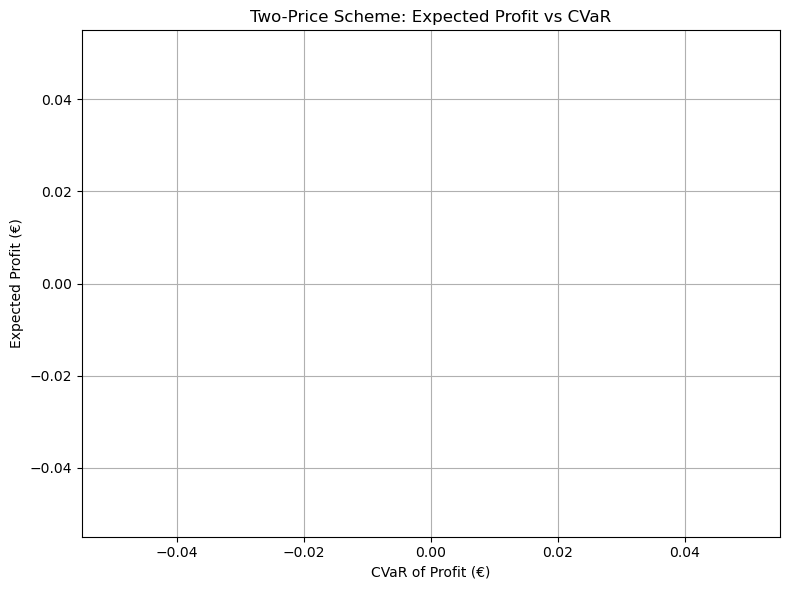

In [28]:
# Expected profit vs CVaR

plt.figure(figsize=(8, 6))
plt.plot(risk_df_2p["CVaR"], risk_df_2p["expected_profit"], marker="o")

for _, row in risk_df_2p.iterrows():
    plt.text(row["CVaR"], row["expected_profit"], f"β={row['beta']:.1f}", fontsize=8)

plt.xlabel("CVaR of Profit (€)")
plt.ylabel("Expected Profit (€)")
plt.title("Two-Price Scheme: Expected Profit vs CVaR")
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Profit distributions

plt.figure(figsize=(10, 6))

for b in selected_betas:
    idx = np.argmin(np.abs(risk_df_2p["beta"].values - b))

    plt.hist(
        risk_profits_2p[idx],
        bins=40,
        alpha=0.45,
        label=f"β = {risk_df_2p.loc[idx, 'beta']:.1f}"
    )

plt.xlabel("Profit (€)")
plt.ylabel("Number of Scenarios")
plt.title("Two-Price Scheme: Profit Distribution under Risk Aversion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'selected_betas' is not defined

<Figure size 1000x600 with 0 Axes>